# 03 — Baseline Model

**Week 4 deliverable: California Property Close Price Prediction**

## Objective

Train a Linear Regression model using the cleaned data from Week 3 and evaluate
its performance on the held-out test month.

The required Week 4 tasks are:

- train Linear Regression,
- calculate test-set R²,
- record the baseline result, and
- briefly explain the model's performance.


## 1. Imports and project paths


In [3]:
from pathlib import Path
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import sparse

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

PROCESSED_DIR = Path("processed")
ARTIFACT_DIR = Path("artifacts")
MODEL_DIR = Path("models")
RESULT_DIR = Path("results")

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)


## 2. Load the Week 3 training and test data

The model uses the same time-based split created during Week 3. The most recent
complete month is reserved for testing, while the previous 12 months are used
for training.


In [5]:
required_files = [
    PROCESSED_DIR / "X_train_preprocessed.npz",
    PROCESSED_DIR / "X_test_preprocessed.npz",
    PROCESSED_DIR / "y_train_close_price.npy",
    PROCESSED_DIR / "y_test_close_price.npy",
    ARTIFACT_DIR / "preprocessing_metadata.json",
]

missing_files = [
    str(path) for path in required_files
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "Run Week 3 first. Missing files:\n"
        + "\n".join(missing_files)
    )

X_train = sparse.load_npz(
    PROCESSED_DIR / "X_train_preprocessed.npz"
)

X_test = sparse.load_npz(
    PROCESSED_DIR / "X_test_preprocessed.npz"
)

y_train = np.load(
    PROCESSED_DIR / "y_train_close_price.npy"
)

y_test = np.load(
    PROCESSED_DIR / "y_test_close_price.npy"
)

with open(
    ARTIFACT_DIR / "preprocessing_metadata.json",
    "r",
    encoding="utf-8"
) as file:
    metadata = json.load(file)

print("Training matrix:", X_train.shape)
print("Testing matrix: ", X_test.shape)
print("Test month:", metadata["test_month"])
print(
    "Training window:",
    metadata["training_window_months"],
    "months"
)

assert X_train.shape[0] == len(y_train)
assert X_test.shape[0] == len(y_test)
assert X_train.shape[1] == X_test.shape[1]


Training matrix: (129972, 822)
Testing matrix:  (12024, 822)
Test month: 2026-05
Training window: 12 months


## 3. Train the Linear Regression baseline


In [7]:
baseline_model = LinearRegression()

baseline_model.fit(
    X_train,
    y_train
)

train_predictions = baseline_model.predict(
    X_train
)

test_predictions = baseline_model.predict(
    X_test
)

print("Linear Regression training complete.")


Linear Regression training complete.


## 4. Evaluate model performance

R² is the primary metric required by the assignment.

- **R²:** proportion of variation in sale price explained by the model.
- **MAE:** average absolute prediction error in dollars.
- **RMSE:** error metric that gives more weight to large mistakes.


In [9]:
train_r2 = r2_score(
    y_train,
    train_predictions
)

test_r2 = r2_score(
    y_test,
    test_predictions
)

test_mae = mean_absolute_error(
    y_test,
    test_predictions
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        test_predictions
    )
)

negative_predictions = int(
    (test_predictions < 0).sum()
)

metrics = pd.DataFrame({
    "Metric": [
        "Training R²",
        "Test R²",
        "Test MAE",
        "Test RMSE",
        "Negative test predictions",
    ],
    "Value": [
        train_r2,
        test_r2,
        test_mae,
        test_rmse,
        negative_predictions,
    ],
})

display(metrics)

print(f"Training R²: {train_r2:.4f}")
print(f"Test R²:     {test_r2:.4f}")
print(f"Test MAE:    ${test_mae:,.0f}")
print(f"Test RMSE:   ${test_rmse:,.0f}")
print(
    "Negative test predictions:",
    negative_predictions
)


,Metric,Value
0,Training R²,2.496047e-02
1,Test R²,3.519918e-01
2,Test MAE,4.739060e+05
3,Test RMSE,1.350821e+06
4,Negative test predictions,3.550000e+02


Training R²: 0.0250
Test R²:     0.3520
Test MAE:    $473,906
Test RMSE:   $1,350,821
Negative test predictions: 355


## 5. Actual versus predicted prices

The dashed diagonal line represents perfect predictions. Points close to this
line are more accurate.

The chart is limited to the 99th percentile so that a small number of extremely
expensive properties do not compress the majority of observations.


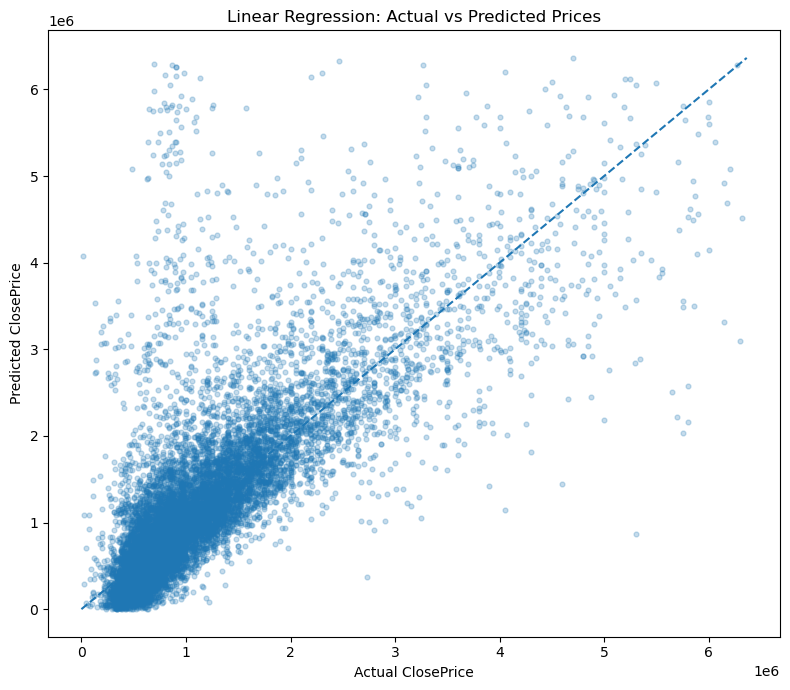

In [11]:
plot_limit = np.quantile(
    np.concatenate([
        y_test,
        np.clip(test_predictions, 0, None),
    ]),
    0.99
)

plot_mask = (
    (y_test <= plot_limit)
    & (test_predictions >= 0)
    & (test_predictions <= plot_limit)
)

plt.figure(figsize=(8, 7))
plt.scatter(
    y_test[plot_mask],
    test_predictions[plot_mask],
    alpha=0.25,
    s=12
)

plt.plot(
    [0, plot_limit],
    [0, plot_limit],
    linestyle="--"
)

plt.xlabel("Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title("Linear Regression: Actual vs Predicted Prices")
plt.tight_layout()
plt.show()


## 6. Residual analysis

A residual is calculated as:

`Actual ClosePrice - Predicted ClosePrice`

Positive residuals indicate underprediction, while negative residuals indicate
overprediction.


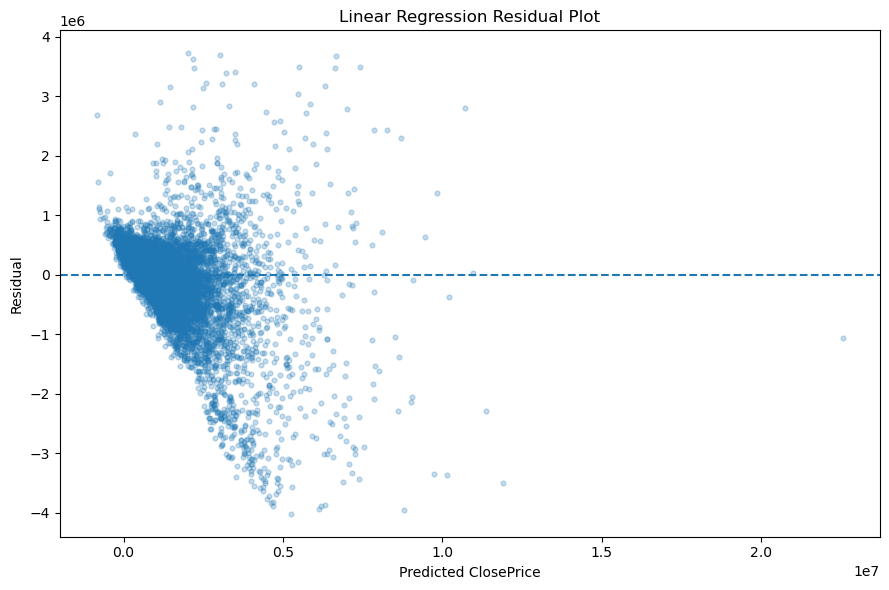

Mean residual: $-64,490
Median residual: $31,656


In [13]:
residuals = y_test - test_predictions

residual_limit = np.quantile(
    np.abs(residuals),
    0.99
)

residual_mask = (
    np.abs(residuals) <= residual_limit
)

plt.figure(figsize=(9, 6))
plt.scatter(
    test_predictions[residual_mask],
    residuals[residual_mask],
    alpha=0.25,
    s=12
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted ClosePrice")
plt.ylabel("Residual")
plt.title("Linear Regression Residual Plot")
plt.tight_layout()
plt.show()

print(
    "Mean residual:",
    f"${residuals.mean():,.0f}"
)

print(
    "Median residual:",
    f"${np.median(residuals):,.0f}"
)


## 7. Save the model and baseline result


In [15]:
joblib.dump(
    baseline_model,
    MODEL_DIR / "linear_regression_baseline.joblib"
)

baseline_results = pd.DataFrame([{
    "Model": "Linear Regression",
    "TestMonth": metadata["test_month"],
    "TrainingWindowMonths":
        metadata["training_window_months"],
    "TrainingRows": len(y_train),
    "TestingRows": len(y_test),
    "TrainR2": train_r2,
    "TestR2": test_r2,
    "TestMAE": test_mae,
    "TestRMSE": test_rmse,
    "NegativePredictions":
        negative_predictions,
}])

baseline_results.to_csv(
    RESULT_DIR / "week4_baseline_results.csv",
    index=False
)

print("Saved model and baseline results.")


Saved model and baseline results.


## 8. Summary

A Linear Regression model was trained using **129,972 property records** from
the 12 months preceding the test period. The model was evaluated on **12,024
properties sold in May 2026**.

### Baseline results

- **Training window:** 12 months
- **Test month:** May 2026
- **Test R²:** 0.3520
- **Test MAE:** approximately $473,906
- **Test RMSE:** approximately $1,350,821
- **Negative predictions:** 355

The test R² of **0.3520** means that the Linear Regression model explained about
**35.2% of the variation** in close prices during the held-out month. This
provides a measurable baseline, but it also shows that a simple linear
relationship cannot fully represent California property prices.

The Actual vs Predicted plot shows that the model follows the general price
trend, but prediction errors become larger for more expensive properties. The
residual plot also shows a wider spread at higher predicted prices, suggesting
that the relationship between the available features and sale price is not
completely linear.

The model produced 355 negative predictions, which are not realistic property
prices. This is another limitation of ordinary Linear Regression. 

Next week, Decision Tree and Random Forest models will be tested to determine whether
nonlinear methods improve test R² and reduce prediction error.


## Week 4 requirement checklist

- [x] Loaded the cleaned Week 3 data
- [x] Trained a Linear Regression model
- [x] Evaluated the model using test-set R²
- [x] Recorded the baseline result
- [x] Created Actual vs Predicted visualization
- [x] Created residual visualization
- [x] Documented model performance and limitations
- [x] Saved the trained model and metrics
